# 1.THRESHOLD

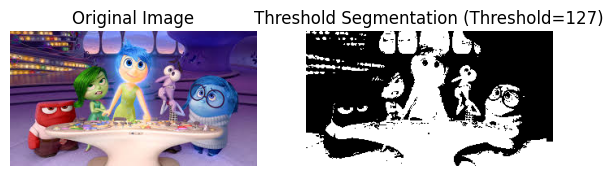

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def threshold_segmentation(image, threshold_value):
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image
    _, thresholded_image = cv2.threshold(image_gray, threshold_value, 255, cv2.THRESH_BINARY)
    return thresholded_image

image = cv2.imread(r"/content/Inside out.jpeg")
threshold_value = 127
segmented_image = threshold_segmentation(image, threshold_value)
plt.figure(figsize=(7, 7))


81
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title(f'Threshold Segmentation (Threshold={threshold_value})')
plt.axis("off")
plt.show()

# 2.REGION GROWING

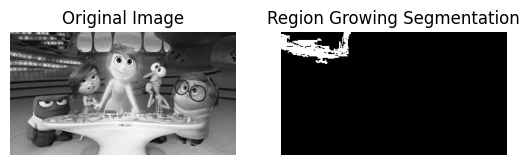

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def region(image, seed, threshold):
    rows, cols = image.shape
    segmented_image = np.zeros_like(image)
    segmented_image[seed] = 255
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    to_process = [seed]

    while to_process:
        current_pixel = to_process.pop()
        x, y = current_pixel
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols:
                if segmented_image[nx, ny] == 0:
                    if abs(int(image[x, y]) - int(image[nx, ny])) <= threshold:
                        segmented_image[nx, ny] = 255
                        to_process.append((nx, ny))
    return segmented_image

image = cv2.imread(r"/content/Inside out.jpeg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

seed = (5, 5)
threshold = 10
segmented_image = region(image_gray, seed, threshold)

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis("off")
plt.subplot(1, 2, 2)
83
plt.imshow(segmented_image, cmap='gray')
plt.title('Region Growing Segmentation')
plt.axis("off")

plt.show()

# 3.K MEANS

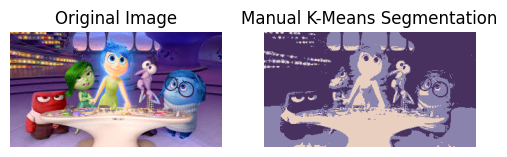

Centroids of K clusters (RGB values):
[[ 72.26960051  48.41478317  95.12275155]
 [233.03674723 207.47811014 191.04803883]
 [137.49578494 131.55815599 173.35736603]]


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def region(image, seed, threshold):
    rows, cols = image.shape
    segmented_image = np.zeros_like(image)
    segmented_image[seed] = 255
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    to_process = [seed]

    while to_process:
        current_pixel = to_process.pop()
        x, y = current_pixel
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols:
                if segmented_image[nx, ny] == 0:
                    if abs(int(image[x, y]) - int(image[nx, ny])) <= threshold:
                        segmented_image[nx, ny] = 255
                        to_process.append((nx, ny))
    return segmented_image

def euclidean_distance(pixels, centroid):
    return np.linalg.norm(pixels - centroid, axis=1)

def kmeans_segmentation(image, K=3, max_iters=100, tol=1e-5):
    pixels = image.reshape((-1, 3))
    np.random.seed(0)
    centroids = pixels[np.random.choice(pixels.shape[0], K, replace=False)]

    # The following line was improperly indented. Removing the extra spaces fixes the issue.
    for _ in range(max_iters):
        distances = np.array([euclidean_distance(pixels, centroid) for centroid in centroids]).T
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([pixels[labels == i].mean(axis=0) for i in range(K)])
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids
    segmented_image = centroids[labels].reshape(image.shape)
    return segmented_image, centroids, labels

# Example usage for k-means segmentation
image = cv2.imread(r"/content/Inside out.jpeg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
segmented_image, centroids, labels = kmeans_segmentation(image_rgb, K=3)
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)  # (rows, columns, index)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(segmented_image.astype(np.uint8))
plt.title('Manual K-Means Segmentation')
plt.axis("off")
plt.show()

print("Centroids of K clusters (RGB values):")
print(centroids)




# 4.GRAPH CUT

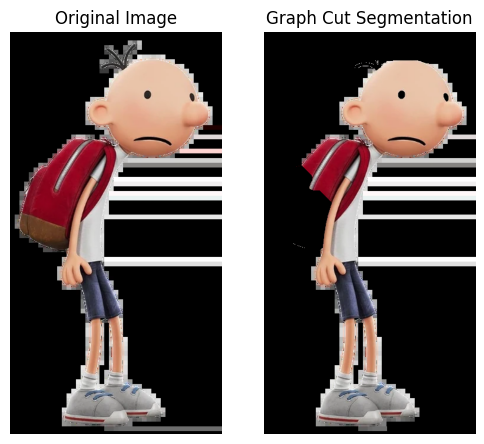

In [4]:
image = cv2.imread(r"/content/greg.webp")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = np.zeros(image.shape[:2], np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
rect = (50, 50, image.shape[1] - 50, image.shape[0] - 50)
cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask == 2) | (mask == 0), 0, 1)
segmented_image = image * mask2[:, :, np.newaxis]
segmented_image = np.uint8(segmented_image)  # Convert to uint8
segmented_image_rgb = cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)  # (rows, columns, index)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis("off")
plt.subplot(1, 2, 2)
86
plt.imshow(segmented_image_rgb)
plt.title('Graph Cut Segmentation')
plt.axis("off")
plt.show()

# 5.MEAN SHIFT

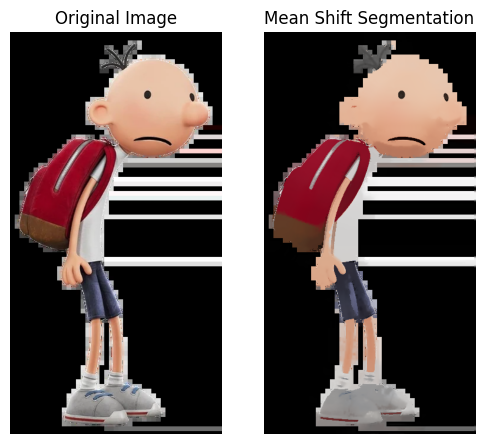

In [5]:
image = cv2.imread(r"/content/greg.webp")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
87
mean_shift_result = cv2.pyrMeanShiftFiltering(image, sp=21, sr=51, maxLevel=1)
mean_shift_result_rgb = cv2.cvtColor(mean_shift_result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mean_shift_result_rgb)
plt.title('Mean Shift Segmentation')
plt.axis("off")
plt.show()